In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

Download the dataset (TMDB_movie_dataset_v11.csv) and put it in the 'data' folder in the same directory as this file.

In [2]:
raw_data = pd.read_csv('data/TMDB_movie_dataset_v11.csv', header=0)

Start of preprocessing steps...

Our objective of data preprocessing:
1. Ensure genres, release_date, and popularity have no missing values.
2. Filter for status == 'Released' and popularity > 0.
3. If a movie has any Escapist tag (Sci-Fi, Fantasy, Animation, Horror, Family, Music), it is Escapist.
4. Remove metadata like backdrop_path, overview, and keywords.
5. Cap years at 2023 to avoid incomplete 2024-2025 data.
-- ?? --
6. Should we cap data to past 20 years from 2023? Unsure...

In [3]:
data = raw_data
print(f"Original data has {len(data)} records.")

data = data[data['status'] == 'Released']

# Delete these unwanted columns
to_ignore = ['id','title','status','backdrop_path', 'poster_path', 'homepage', 'imdb_id', 'tagline', 'overview','production_companies','keywords','original_title']
data = data.drop(columns=to_ignore)

data = data.dropna(subset=['release_date', 'popularity', 'genres'])
data = data[data['popularity'] > 0]

data['release_date'] = pd.to_datetime(data['release_date'])
data['year'] = data['release_date'].dt.year
data = data[(data['year'] >= 2008) & (data['year'] <= 2026)]

Original data has 1395267 records.


We need to set some initial assumptions in order to set ourselves for success. After careful analysis of dataset and its values, we chose to classify the following genres as "Escapist" and "Realists".

In [4]:
escapist = ['Science Fiction', 'Fantasy', 'Animation', 'Horror', 'Family', 'Music', 'Mystery']
realist = ['Drama', 'History', 'Documentary', 'War', 'Crime', 'Western','Romance']

We decided to use the strategy of "Dominant trait contamination". If the movie contains any genre that is subset of escapist, that essentially changes the entire voice and tone of the movie to be escapist. Hence we set that movie as escapist.

In [5]:
def assign_dominant_class(genre_str, e_tags, r_tags):
    movie_genres = {g.strip() for g in str(genre_str).split(',')}
    
    if movie_genres.intersection(e_tags):
        return 'Escapist'
    
    if movie_genres.intersection(r_tags):
        return 'Realist'
        
    return 'Other'



data['dominant_class'] = data['genres'].apply(lambda x: assign_dominant_class(x, set(escapist), set(realist)))

data['is_escapist'] = data['dominant_class'] == 'Escapist'
data['is_realist'] = data['dominant_class'] == 'Realist'

data = data[data['dominant_class'] != 'Other']

data = data[(data['runtime'] >= 45)&(data['runtime'] <= 300)]

In [6]:
print(f"Processed data has {len(data)} records.")
print(f"Processed data has {data['is_realist'].sum()} realist movies.")
print(f"Processed data has {data['is_escapist'].sum()} escapist movies.")
data.head(10)

Processed data has 154318 records.
Processed data has 105577 realist movies.
Processed data has 48741 escapist movies.


,vote_average,vote_count,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_countries,spoken_languages,year,dominant_class,is_escapist,is_realist
0,8.364,34495,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","United Kingdom, United States of America","English, French, Japanese, Swahili",2010,Escapist,True,False
1,8.417,32571,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","United Kingdom, United States of America",English,2014,Escapist,True,False
2,8.512,30619,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","English, Mandarin",2008,Realist,False,True
3,7.573,29815,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","English, Spanish",2009,Escapist,True,False
4,7.710,29166,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",United States of America,"English, Hindi, Russian",2012,Escapist,True,False
6,8.255,27713,2018-04-25,2052415039,149,False,300000000,en,154.340,"Adventure, Action, Science Fiction",United States of America,"English, Xhosa",2018,Escapist,True,False
8,7.906,26638,2014-07-30,772776600,121,False,170000000,en,33.255,"Action, Science Fiction, Adventure",United States of America,English,2014,Escapist,True,False
12,7.640,24874,2008-04-30,585174222,126,False,140000000,en,72.897,"Action, Science Fiction, Adventure",United States of America,"English, Persian, Urdu, Arabic",2008,Escapist,True,False
13,8.171,24672,2012-12-25,425368238,165,False,100000000,en,54.224,"Drama, Western",United States of America,"English, French, German",2012,Realist,False,True
15,8.263,23857,2019-04-24,2800000000,181,False,356000000,en,91.756,"Adventure, Science Fiction, Action",United States of America,"English, Japanese, Xhosa",2019,Escapist,True,False


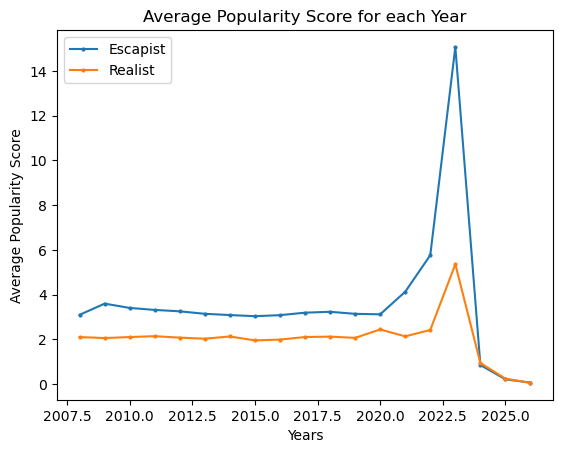

In [7]:
years = data['year'].to_numpy()
years = np.unique(years)
avg_popularity_e = []
avg_popularity_r = []

for year in years:
    avg_popularity_e += [data[(data['year']==year)&(data['is_escapist'])]['popularity'].mean()]
    avg_popularity_r += [data[(data['year']==year)&(data['is_realist'])]['popularity'].mean()]

plt.plot(years, avg_popularity_e, label='Escapist', marker='o', ms=2)
plt.plot(years, avg_popularity_r, label='Realist', marker='o', ms=2)
plt.xlabel('Years')
plt.ylabel('Average Popularity Score')
plt.title('Average Popularity Score for each Year')
plt.legend()
plt.show()

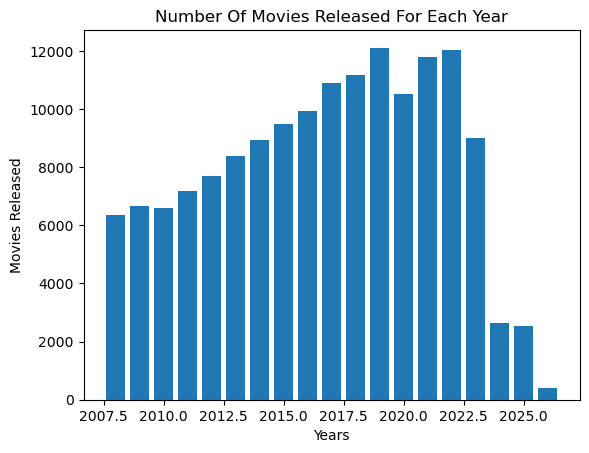

In [8]:
movies_per_year = []
for year in years:
    movies_per_year += [data[(data['year']==year)]['year'].count()]

plt.bar(years, movies_per_year)
plt.xlabel('Years')
plt.ylabel('Movies Released')
plt.title('Number Of Movies Released For Each Year')
plt.show()

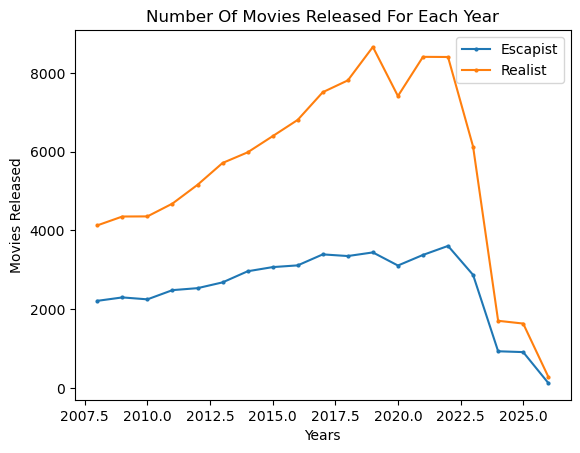

In [9]:
escapist_per_year = []
realist_per_year = []

for year in years:
    escapist_per_year += [data[(data['year']==year)&(data['is_escapist'])]['year'].count()]
    realist_per_year += [data[(data['year']==year)&(data['is_realist'])]['year'].count()]
#print(movies_per_year)

plt.plot(years, escapist_per_year, label='Escapist', marker='o', ms=2)
plt.plot(years, realist_per_year, label='Realist', marker='o', ms=2)
plt.xlabel('Years')
plt.ylabel('Movies Released')
plt.title('Number Of Movies Released For Each Year')
plt.legend()
plt.show()

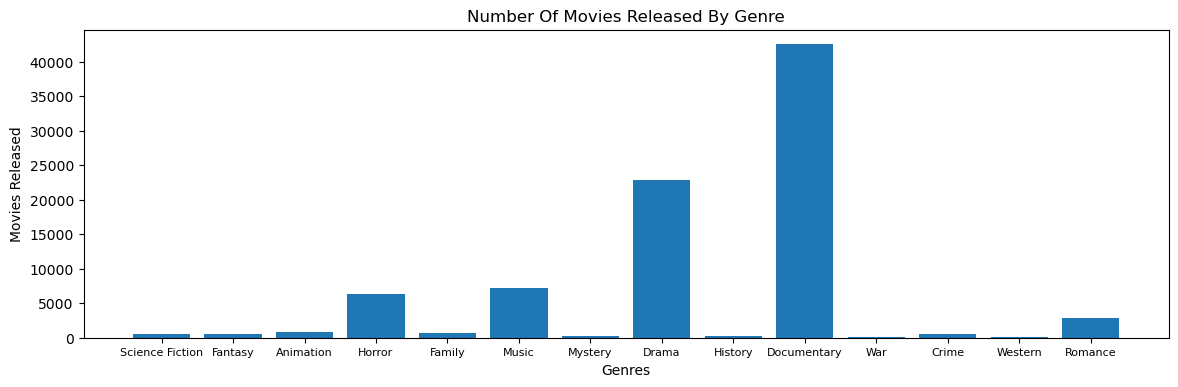

In [10]:
genres = escapist + realist
genre_counts = []

for g in genres:
    genre_counts += [data[(data['genres']==g)]['genres'].count()]

plt.figure(figsize=(14,4))
plt.bar(genres, genre_counts)
plt.xlabel('Genres')
plt.xticks(fontsize=8)
plt.ylabel('Movies Released')
plt.title('Number Of Movies Released By Genre')
plt.show()

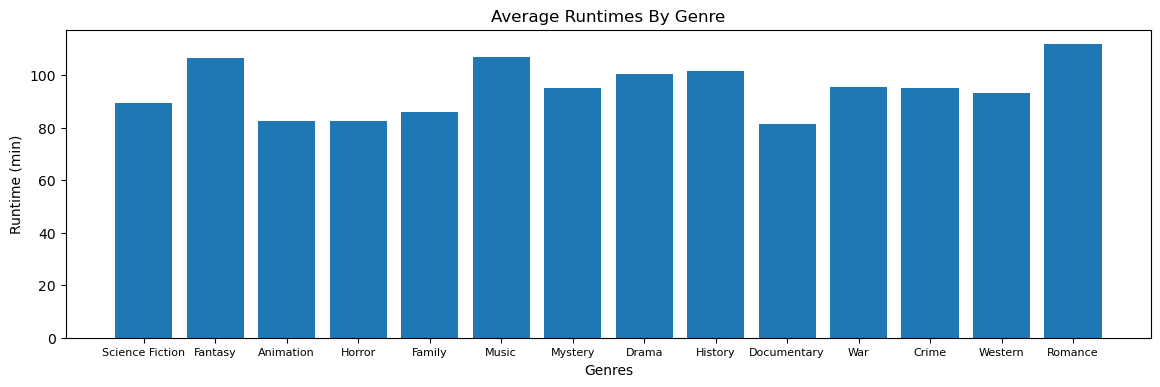

In [11]:
genre_avg_runtimes = []

for g in genres:
    genre_avg_runtimes += [data[(data['genres']==g)]['runtime'].mean()]

plt.figure(figsize=(14,4))
plt.bar(genres, genre_avg_runtimes)
plt.xlabel('Genres')
plt.xticks(fontsize=8)
plt.ylabel('Runtime (min)')
plt.title('Average Runtimes By Genre')
plt.show()

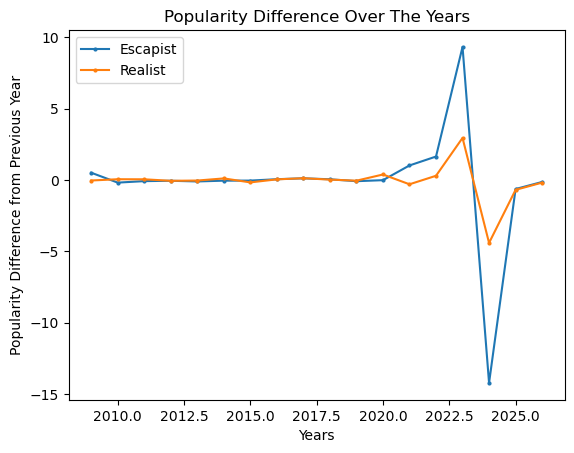

In [12]:
popularity_data = pd.DataFrame({'year':years, 'escapist_pop':avg_popularity_e, 'realist_pop':avg_popularity_r})
popularity_data = popularity_data.dropna()
popularity_data['escapist_diff'] = popularity_data['escapist_pop'].diff()
popularity_data['realist_diff'] = popularity_data['realist_pop'].diff()
popularity_data = popularity_data.dropna()

popularity_data.head(5)

plt.plot(popularity_data['year'], popularity_data['escapist_diff'], label='Escapist', marker='o', ms=2)
plt.plot(popularity_data['year'], popularity_data['realist_diff'], label='Realist', marker='o', ms=2)
plt.xlabel('Years')
plt.ylabel('Popularity Difference from Previous Year')
plt.title('Popularity Difference Over The Years')
plt.legend()
plt.show()

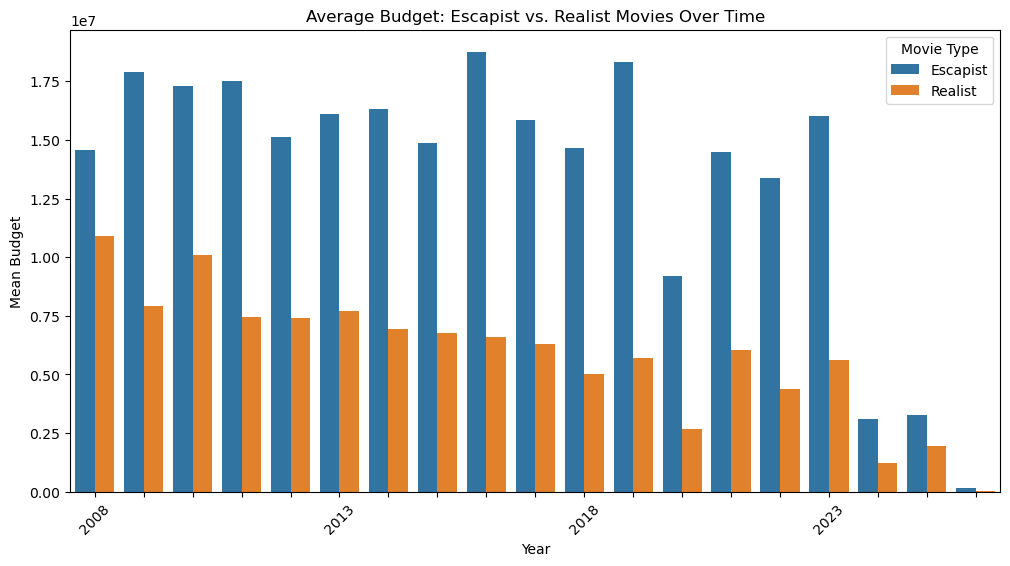

In [13]:
yearly_budget = data[data['budget'] > 0].groupby(['year', 'dominant_class'])['budget'].mean().reset_index()

# Plotting the comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_budget, x='year', y='budget', hue='dominant_class')

# Formatting for readability
plt.xticks(rotation=45)
plt.title('Average Budget: Escapist vs. Realist Movies Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Budget')
plt.legend(title='Movie Type')

# Thinning out x-ticks if there are too many years
for ind, label in enumerate(plt.gca().get_xticklabels()):
    if ind % 5 == 0:  # Show every 5th year
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.show()

In [14]:
escapist_budgets = data[data['dominant_class'] == 'Escapist']['budget']
realist_budgets = data[data['dominant_class'] == 'Realist']['budget']

# Running One-Way ANOVA
f_stat, p_val = stats.f_oneway(escapist_budgets, realist_budgets)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

F-Statistic: 750.7275
P-Value: 6.9426e-165


<Figure size 1200x800 with 0 Axes>

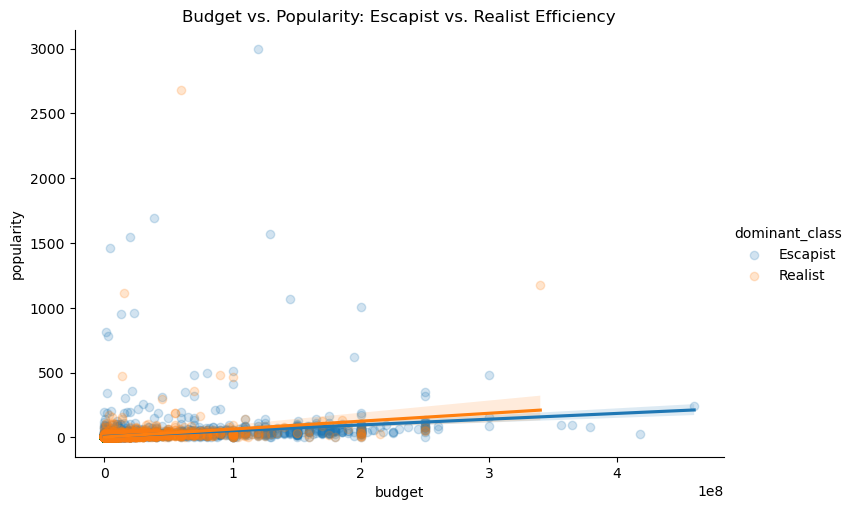

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     359.9
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          6.39e-225
Time:                        22:17:15   Log-Likelihood:                -72999.
No. Observations:               13582   AIC:                         1.460e+05
Df Residuals:                   13578   BIC:                         1.460e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [15]:
import statsmodels.formula.api as smf

# Filter for rows with budget and popularity > 0
df_filtered = data[(data['budget'] > 0) & (data['popularity'] > 0)]

plt.figure(figsize=(12, 8))
sns.lmplot(data=df_filtered, x='budget', y='popularity', hue='dominant_class', 
           scatter_kws={'alpha':0.2}, aspect=1.5)

plt.title('Budget vs. Popularity: Escapist vs. Realist Efficiency')
plt.show()

model = smf.ols(formula="popularity ~ budget * dominant_class", data=df_filtered).fit()

print(model.summary())

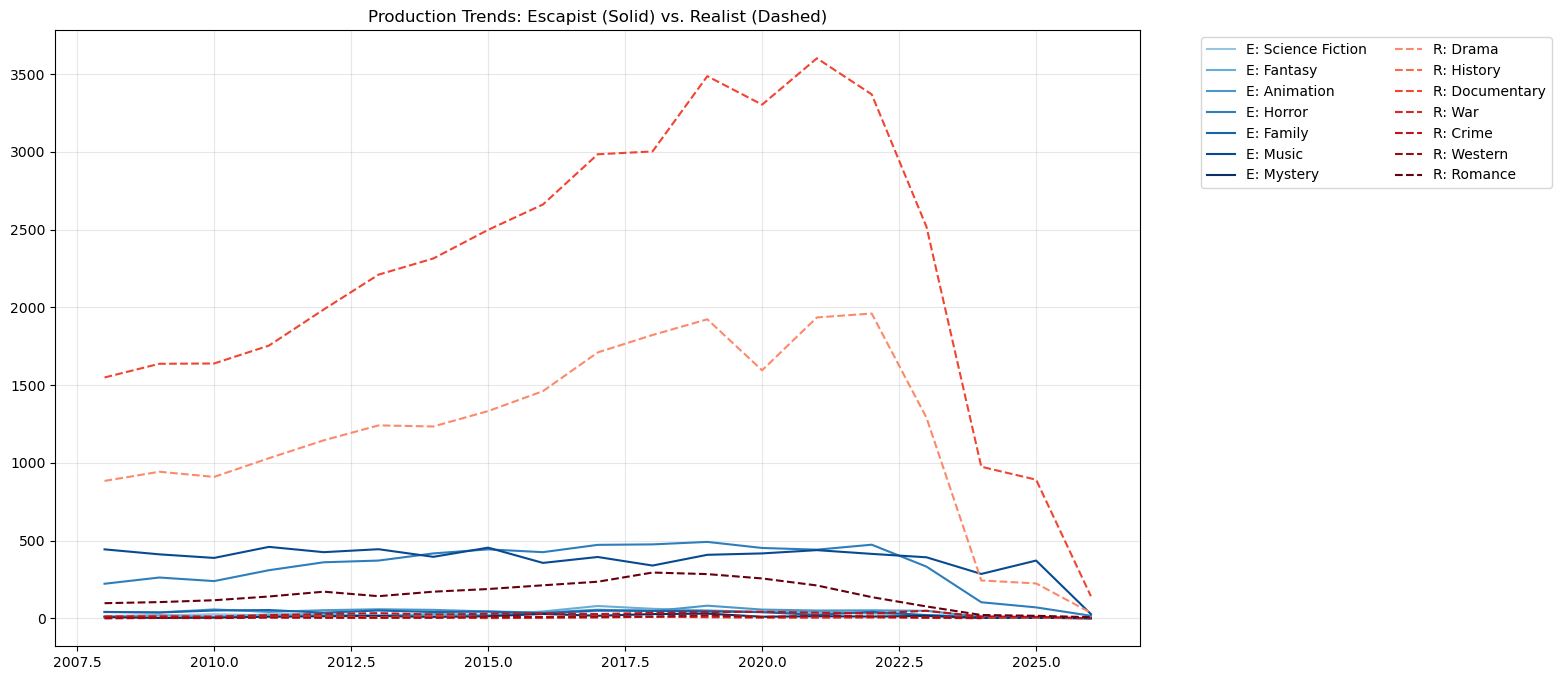

In [16]:
genre_yearly = data.groupby(['year', 'genres']).size().reset_index(name='count')

# Filter for your specific escapist and realist genres
target_genres = escapist + realist
filtered_yearly = genre_yearly[genre_yearly['genres'].isin(target_genres)]
# Create a color mapping based on your classification
palette = {}
for g in escapist: palette[g] = 'Blues'
for g in realist: palette[g] = 'Reds'

plt.figure(figsize=(14, 8))

# Plot Escapist genres with solid lines
for i, g in enumerate(escapist):
    subset = filtered_yearly[filtered_yearly['genres'] == g]
    plt.plot(subset['year'], subset['count'], label=f"E: {g}", 
             color=plt.cm.Blues(0.4 + (i*0.1)), linestyle='-')

# Plot Realist genres with dashed lines
for i, g in enumerate(realist):
    subset = filtered_yearly[filtered_yearly['genres'] == g]
    plt.plot(subset['year'], subset['count'], label=f"R: {g}", 
             color=plt.cm.Reds(0.4 + (i*0.1)), linestyle='--')

plt.title('Production Trends: Escapist (Solid) vs. Realist (Dashed)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

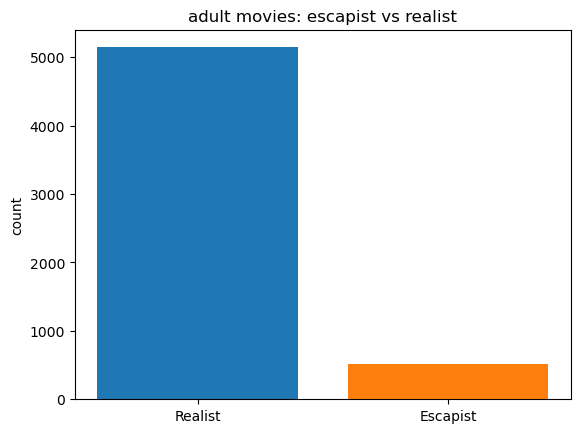

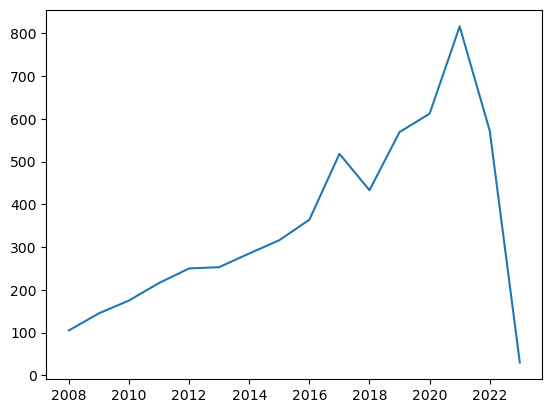

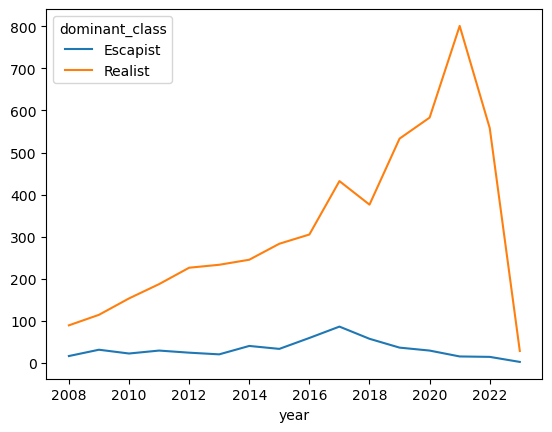

In [17]:
# filter for adult content and count by category [cite: 46, 58]
adult_counts = data[data['adult'] == True]['dominant_class'].value_counts()

plt.bar(adult_counts.index, adult_counts.values, color=['#1f77b4', '#ff7f0e'])
plt.title('adult movies: escapist vs realist')
plt.ylabel('count')
plt.show()

adult_year = data[data['adult'] == True].groupby('year').size()
plt.plot(adult_year.index, adult_year.values)
plt.show()

adult_trends = data[data['adult'] == True].groupby(['year', 'dominant_class']).size().unstack()
adult_trends.plot()
plt.show()

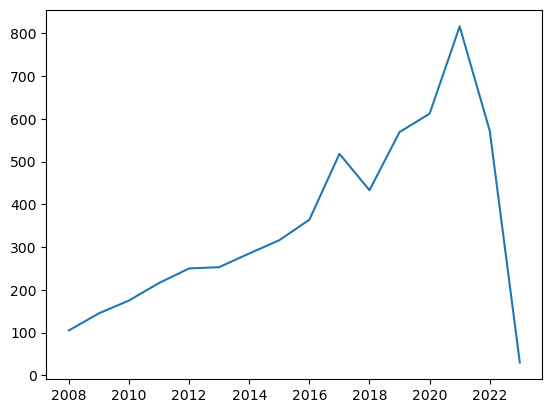

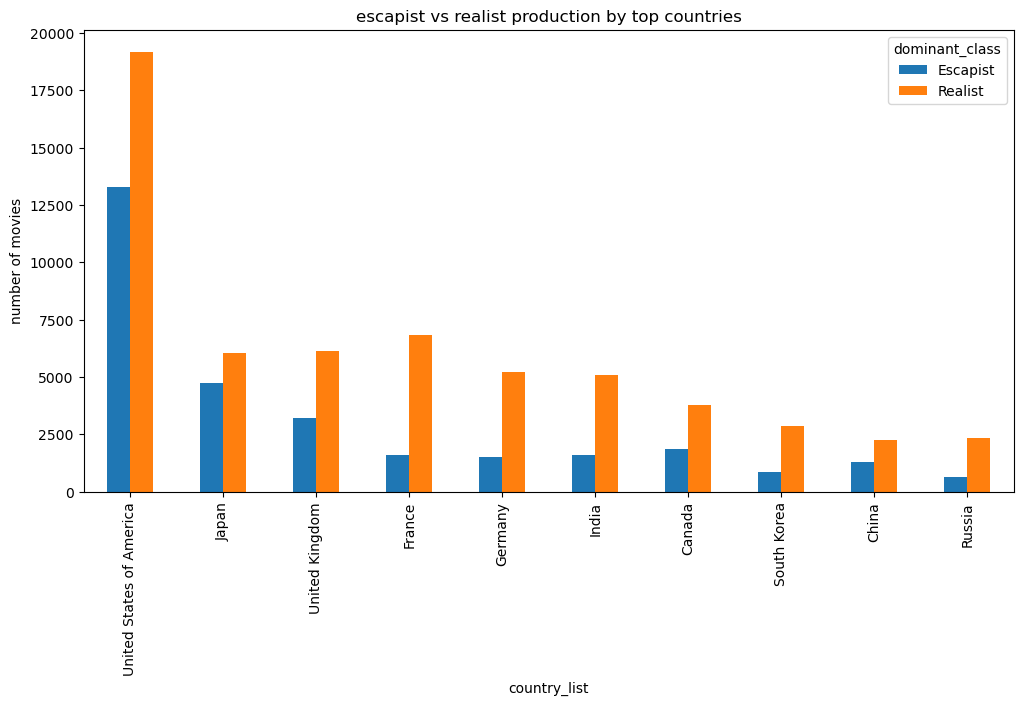

In [18]:
adult_year = data[data['adult'] == True].groupby('year').size()
plt.plot(adult_year.index, adult_year.values)
plt.show()

# 1. Split the strings into lists and explode
data['country_list'] = data['production_countries'].str.split(', ')
data_exploded = data.explode('country_list')

# 2. Group by country and category
country_breakdown = data_exploded.groupby(['country_list', 'dominant_class']).size().unstack(fill_value=0)

# 3. Filter for top 10 countries to keep the chart readable
top_countries = country_breakdown.sum(axis=1).sort_values(ascending=False).head(10).index
country_plot_data = country_breakdown.loc[top_countries]

# 4. Plot
country_plot_data.plot(kind='bar', figsize=(12, 6))
plt.title('escapist vs realist production by top countries')
plt.ylabel('number of movies')
plt.show()

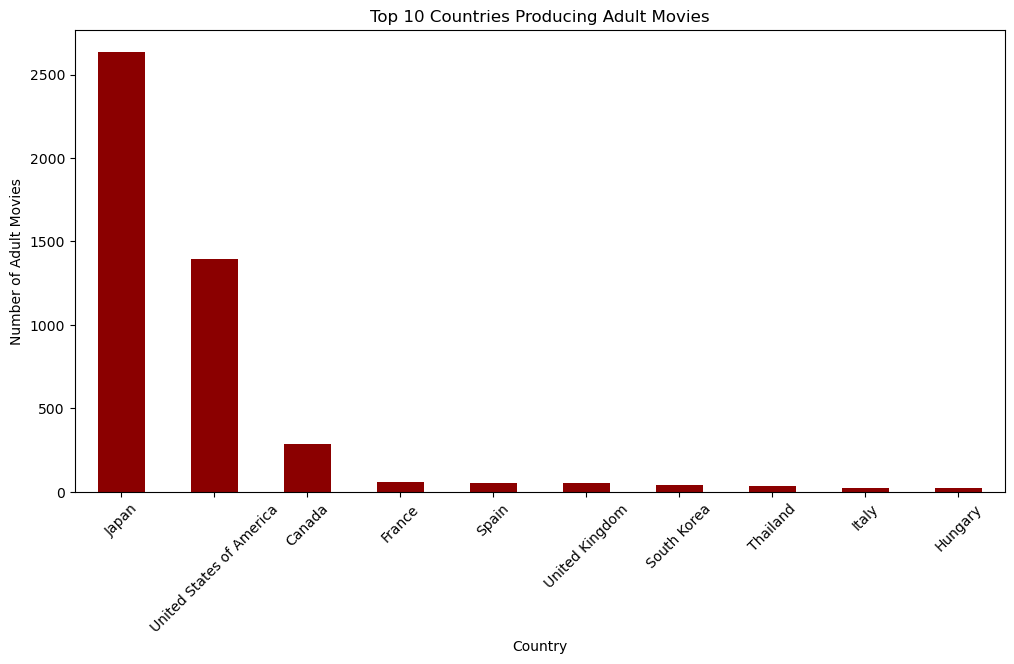

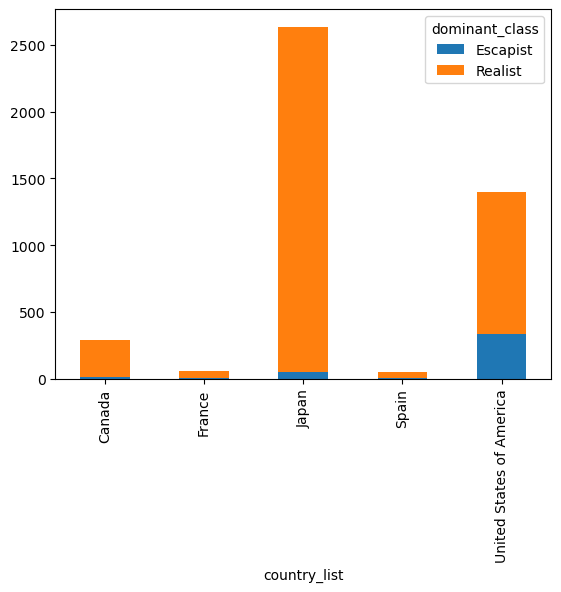

In [19]:
# 1. Filter for adult movies only
adult_only = data[data['adult'] == True].copy()

# 2. Split and explode the production_countries column
# This handles entries like "United Kingdom, United States of America" 
adult_only['country_list'] = adult_only['production_countries'].str.split(', ')
adult_exploded = adult_only.explode('country_list')

# 3. Count adult movies by country and take the top 10
top_adult_countries = adult_exploded['country_list'].value_counts().head(10)

# 4. Plot the results
plt.figure(figsize=(12, 6))
top_adult_countries.plot(kind='bar', color='darkred')
plt.title('Top 10 Countries Producing Adult Movies')
plt.xlabel('Country')
plt.ylabel('Number of Adult Movies')
plt.xticks(rotation=45)
plt.show()

top_c = adult_exploded['country_list'].value_counts().head(5).index
adult_exploded[adult_exploded['country_list'].isin(top_c)].groupby(['country_list', 'dominant_class']).size().unstack().plot(kind='bar', stacked=True)
plt.show()

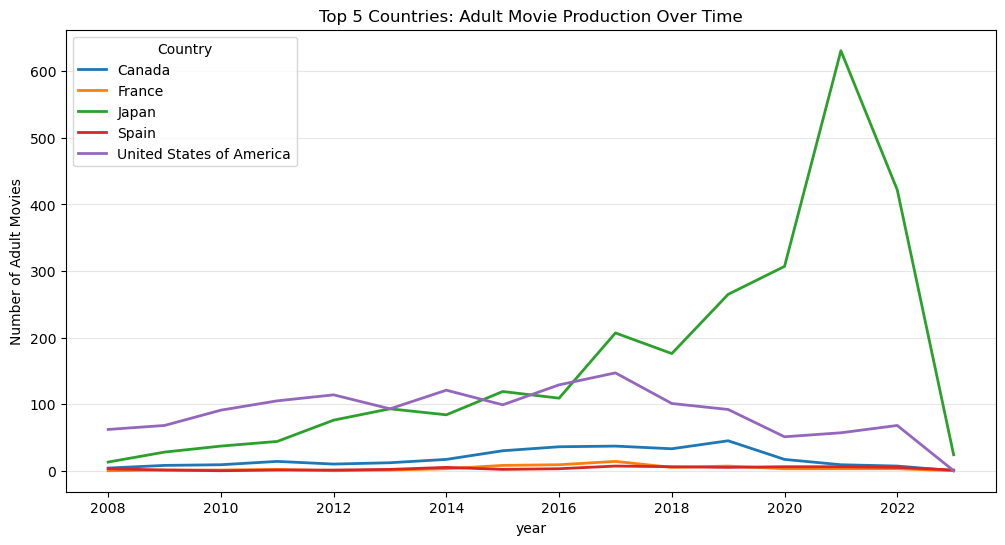

In [20]:
# 1. Process and explode the country data
adult_only = data[data['adult'] == True].copy()
adult_only['country_list'] = adult_only['production_countries'].str.split(', ')
df_exploded = adult_only.explode('country_list')

# 2. Identify the top 5 countries by total volume
top_5_countries = df_exploded['country_list'].value_counts().head(5).index

# 3. Filter and pivot for the line chart
df_top_5 = df_exploded[df_exploded['country_list'].isin(top_5_countries)]
trend_data = df_top_5.groupby(['year', 'country_list']).size().unstack(fill_value=0)

# 4. Plot
trend_data.plot(figsize=(12, 6), linewidth=2)
plt.title('Top 5 Countries: Adult Movie Production Over Time')
plt.ylabel('Number of Adult Movies')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Country')
plt.show()

Pearson Correlation (r): 0.2680
P-value: 4.9675e-222


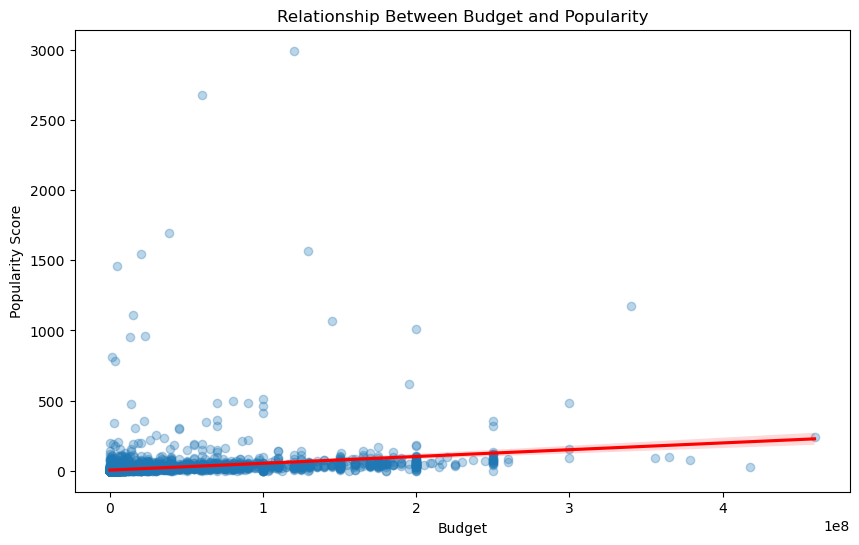

In [21]:
budget_data = data[data['budget'] > 0]
r, p_value = stats.pearsonr(budget_data['budget'], budget_data['popularity'])

print(f"Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p_value:.4e}")

# 2. Scatter plot with Linear Regression
plt.figure(figsize=(10, 6))
sns.regplot(data=budget_data, x='budget', y='popularity', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship Between Budget and Popularity')
plt.xlabel('Budget')
plt.ylabel('Popularity Score')
plt.show()

In [31]:
import scipy.stats as stats

e_pop_mean = np.mean(avg_popularity_e[:13])
e_pop_std = np.std(avg_popularity_e[:13])
r_pop_mean = np.mean(avg_popularity_r[:13])
r_pop_std = np.std(avg_popularity_r[:13])

e_2023 = np.mean(avg_popularity_e[13:16])
r_2023 = np.mean(avg_popularity_r[13:16])

e_z_score = (e_2023 - e_pop_mean)/e_pop_std
r_z_score = (r_2023 - r_pop_mean)/r_pop_std

e_p_value = stats.norm.sf(e_z_score)
r_p_value = stats.norm.sf(r_z_score)

print(f'Escapist Z-Score: {e_z_score}')
print(f'Realist Z-Score: {r_z_score}')
print(f'Escapist P-Value: {e_p_value}')
print(f'Realist P-Value: {r_p_value}')

Escapist Z-Score: 33.99949252575963
Realist Z-Score: 10.74882830289798
Escapist P-Value: 1.1333016380553523e-253
Realist P-Value: 3.0009587256096046e-27
